In [1]:
# 01_data_exploration.ipynb - EDA & Data Testing

import sys, os
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt

print("Python:", sys.version)
print("Pandas:", pd.__version__)
import sklearn; print("sklearn:", sklearn.__version__)



Python: 3.11.1 (tags/v3.11.1:a7a450f, Dec  6 2022, 19:58:39) [MSC v.1934 64 bit (AMD64)]
Pandas: 3.0.1
sklearn: 1.8.0


In [4]:
# Load data
df = pd.read_csv('../data/raw/train.csv')
print("Data shape:", df.shape)
df.head()


Data shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Missing values & Duplicates
print("Missing values statistics:\n", df.isnull().sum()[lambda x: x>0])
print("Duplicate rows:", df.duplicated().sum())


Missing values statistics:
 Age         177
Cabin       687
Embarked      2
dtype: int64
Duplicate rows: 0


In [6]:
# Outlier example: Fare
Q1, Q3 = df['Fare'].quantile([0.25, 0.75])
IQR = Q3 - Q1
o = df[(df['Fare'] < Q1 - 1.5*IQR) | (df['Fare'] > Q3 + 1.5*IQR)]
print("Fare outlier rows:", len(o))


Fare outlier rows: 116


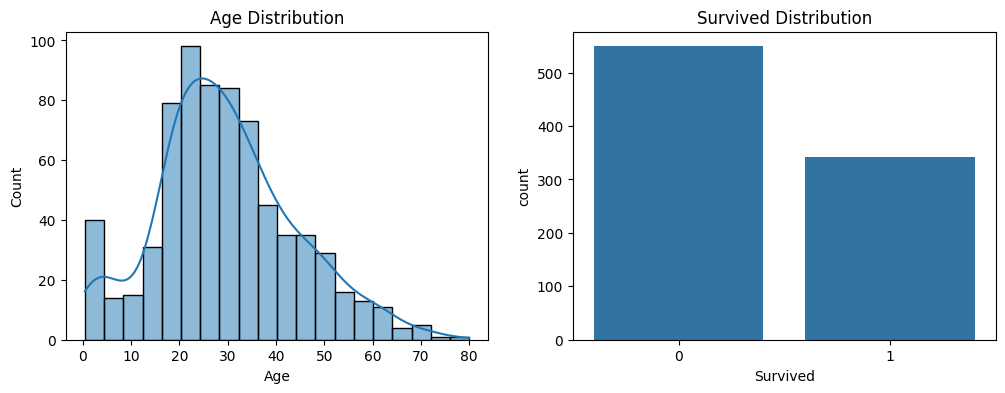

In [7]:
# Distribution visualization
fig, axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0]).set_title("Age Distribution")
sns.countplot(x='Survived', data=df, ax=axes[1]).set_title("Survived Distribution")
plt.show()


In [8]:
# Save initial exploration data
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/train_raw.csv', index=False)
print("Saved: data/processed/train_raw.csv")


Saved: data/processed/train_raw.csv
